# AP 155 Lab Exercise
---
## Exercise 4
: Derivatives

_Instructions_: 
- **Output 1: Finite Difference** Functions and plots of finite-difference methods
- **Output 2: Harmonic Oscillator** Error analysis plot of finite-difference methods.
  
### Student Information
- _Full Name (Last Name, First Name)_: Gonzales, Naeumi
- _Student No._: 2024-11022
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1: Finite Difference

![Finite-Difference vs. Analytical Solution](finite_analytical.png)

Figure 1. Finite-Difference vs. Analytical Solution

Figure 1 illustrates the comparison between three ways of calculating f'(x) and the exact analytical answer. The points of the forward difference are sitting mostly on the left side, while the backward difference shows the opposite. The forward difference's use of points ahead of x causes bias toward where the curve heads. The backward difference's use of points before x causes bias toward where the curve originates. This bias flips direction exactly at x = 0 due to the upward curve before the peak and downward following it. These biases are cancelled in the central difference due to its equal usage of points on both sides, causing its points to be almost identical to the analytical curve. 


### Problem 2: Simple Harmonic Oscillator

![Numerical Differentiation Error vs. Analytical Solution](numerical_analytical.png)

Figure 2. Error of Numerical Differentiation vs. Analytical Solution at t=t0

Figure 2 illustrates the error of the backward and central difference methods at t0 = 0, 1, and 2. When the step size is small, the trend is a straight line as expected, but once it increases, the curves show deviation due to the approximations' accuracy being limited to only small h. The central difference shows much higher accuracy due to its error starting smaller and growing more slowly. The curve of the backward difference dips down around h = 1.3 before it rises again because the non-absolute error starts negative and crosses through zero approximately around that point. Taking its absolute value causes it to touch near zero before it grows again on the other side.

### Other comments
- none


---
## Section 2: Code

### Problem 1: Finite Difference

Let $$f(x) = 1+\frac{1}{2}\tanh(2x)$$

**(a)** Create functions that take as input an array or list of points corresponding to a mathematical function and output the derivative using **(a.1)** forward-difference, **(a.2)** backward-difference, and **(a.3)** central-difference methods.


In [35]:
import numpy as np
import matplotlib.pyplot as plt

#Setup
x = np.linspace(-3, 3, 100) #creates a 1D array that has 100 evenly spaced values that span from -3 to 3
h = x[1] - x[0] #uniformly spaced grid, used as the step size
y = f(x)

def f(x):
    return 1 + 0.5*np.tanh(2*x)

#analytic derivative
def fprime(x):
    return (1 - np.tanh(2*x)**2)

#forward difference
def for_diff(f, x, h):
    fd = ((f(x+h) - f(x))/h)
    return fd
    
#backward difference
def back_diff(f, x, h):
    bd = ((f(x) - f(x-h))/h)
    return bd

#central difference
def central_diff(f, x, h):
    cd = ((f(x+h/2) - f(x-h/2))/h)
    return cd

y_exact = fprime(x)
y_fd = for_diff(f, x, h)
y_bd = back_diff(f, x, h)
y_cd = central_diff(f, x, h)

**(b)** Calculate an analytic formula for the derivative. Make three subplots for the derivative of $f'(x)$, one for each method and the analytic answer on the same plots. Plot the exact answer (use `numpy`) as lines and the numerical one as dots. Describe how the two results compare. Use `plt.subplots`

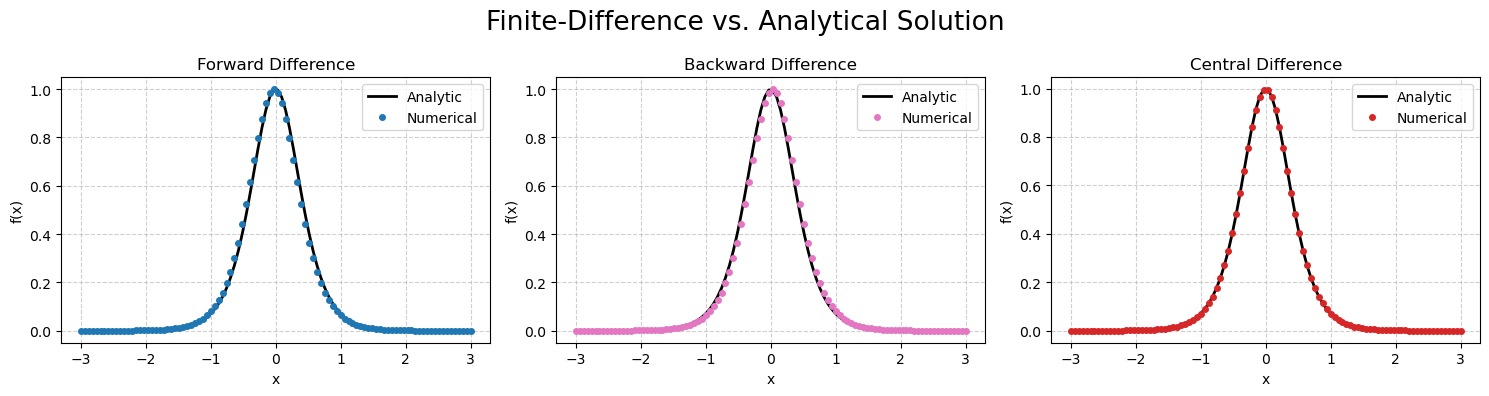

In [34]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

ax1.plot(x, y_exact, 'k-', label="Analytic", linewidth=2)
ax1.plot(x, y_fd, 'o', label="Numerical", color='tab:blue', markersize=4)
ax1.set_title("Forward Difference")
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.plot(x, y_exact, 'k-', label="Analytic", linewidth=2)
ax2.plot(x, y_bd, 'o', label="Numerical", color='tab:pink', markersize=4)
ax2.set_title("Backward Difference")
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

ax3.plot(x, y_exact, 'k', label="Analytic", linewidth=2)
ax3.plot(x, y_cd, 'o', label='Numerical', color='tab:red', markersize=4)
ax3.set_title("Central Difference")
ax3.set_xlabel('x')
ax3.set_ylabel('f(x)')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend()

fig.suptitle("Finite-Difference vs. Analytical Solution", fontsize=19)
plt.tight_layout()
plt.savefig('finite_analytical.png')
plt.show()

* Evaluation of three varying numerical differentiation methods where done in this code by utilizing three separate functions, while also doing a comparison between their outputs and the exact differential derivative. Instead of choosing an arbitrary value, the grid spacing (x[1] - x[0]) was utilized for the step size h for the resolution of the approximation and the plotted grid to match. For the visualization of their comparison, three side-by-side subplots were used for plotting.

### Problem 2: Simple Harmonic Oscillator

The position $x(t)$ of a 1D simple harmonic oscillator is described by the equation of motion:

$$-kx = \frac{d^2x}{dt^2}$$

We know a solution can take the form of $x(t) = \cos(t)$. Calculate the velocity of this particle using any finite-difference method, and plot its absolute error with respect to the analytical value by varying your step-sizes. The absolute error should have the same trend as the $\mathcal{O}$ error of your chosen method.

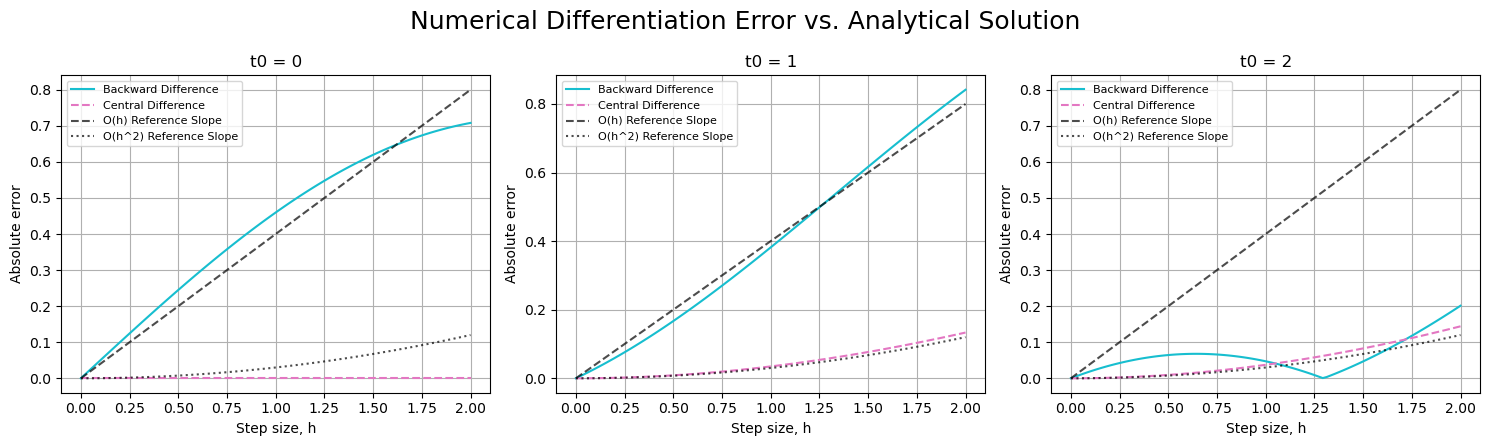

In [32]:
import numpy as np
import matplotlib.pyplot as plt

#position
def x(t):
    return np.cos(t)

#velocity obtained from analytical solution
def exact_v(t):
    return -np.sin(t)

#backward finite difference, O(h)
def back_v(t, h):
    return (x(t) - x(t-h))/h

#central finite difference
def central_v(t, h):
    return (x(t+h/2) - x(t-h/2))/h
    
h_val = np.linspace(0.0001, 2, 100) #step sizes' range
t0_val = [0, 1, 2] #evaluation points

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, t0 in zip(axes, t0_val):
    true_v = exact_v(t0)

    #computing absolute errors
    error_backward = [np.abs(back_diff(x, t0, h) - true_v) for h in h_val]
    error_central = [np.abs(central_diff(x, t0, h) - true_v) for h in h_val]


    ax.plot(h_val, error_backward, '-', label='Backward Difference', color='tab:cyan')
    ax.plot(h_val, error_central, '--', label='Central Difference', color='tab:pink')
    ax.plot(h_val, 0.4*h_val, 'k--', label='O(h) Reference Slope', alpha=0.7)
    ax.plot(h_val, 0.03*h_val**2, 'k:', label='O(h^2) Reference Slope', alpha=0.7)

    ax.set_title(f"t0 = {t0}")
    ax.set_xlabel("Step size, h")
    ax.set_ylabel("Absolute error")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.suptitle("Numerical Differentiation Error vs. Analytical Solution", fontsize=18)
plt.tight_layout()
plt.savefig('numerical_analytical.png')
plt.show()   

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

* Comparison between the exact velocity of x(t) = cos(t), which is v(t) = -sin(t), and the backward and central differences was done in the code to illustrate how the error reduces as the step size decreases. This is done through a loop over a range of small h values, calculating each approximation, finding the difference from the true value, and plotting it with matplotlib.

---
## Section 3: Tutorials

### Derivatives

The derivate of a function $f(x) $ can be approximated using the **forward difference** as

$$f'(x) = \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)$$

using the **backward difference**

$$f'(x) = \frac{f(x) - f(x-h)}{h} + \mathcal{O}(h)$$

and the **central difference**

$$f'(x) = \frac{f(x + \frac{h}{2}) - f(x - \frac{h}{2})}{h} + \mathcal{O}(h^2)$$

where $h$ is a small step-size. To minimzie error, you can use Richardson Extrapolation, which can be found on the book (Gezerlis).

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

### Basics

In [ ]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

In [ ]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

### Control flow

In [ ]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

In [ ]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

In [ ]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

In [ ]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

### Data structures

In [ ]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

In [ ]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

In [ ]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

In [ ]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

In [ ]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

In [ ]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

In [ ]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

In [ ]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

### User-defined functions

In [ ]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

In [ ]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

In [ ]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [ ]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

In [ ]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

In [ ]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [ ]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

In [ ]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments